In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats 

In [4]:
data = pd.read_csv("modified_c4_epa_air_quality.csv")

In [5]:
data.head(10)

,date_local,state_name,county_name,city_name,local_site_name,parameter_name,units_of_measure,aqi_log
0,2018-01-01,Arizona,Maricopa,Buckeye,BUCKEYE,Carbon monoxide,Parts per million,2.079442
1,2018-01-01,Ohio,Belmont,Shadyside,Shadyside,Carbon monoxide,Parts per million,1.791759
2,2018-01-01,Wyoming,Teton,Not in a city,Yellowstone National Park - Old Faithful Snow ...,Carbon monoxide,Parts per million,1.098612
3,2018-01-01,Pennsylvania,Philadelphia,Philadelphia,North East Waste (NEW),Carbon monoxide,Parts per million,1.386294
4,2018-01-01,Iowa,Polk,Des Moines,CARPENTER,Carbon monoxide,Parts per million,1.386294
5,2018-01-01,Hawaii,Honolulu,Not in a city,Kapolei,Carbon monoxide,Parts per million,2.708050
6,2018-01-01,Hawaii,Honolulu,Not in a city,Kapolei,Carbon monoxide,Parts per million,1.098612
7,2018-01-01,Pennsylvania,Erie,Erie,NaN,Carbon monoxide,Parts per million,1.098612
8,2018-01-01,Hawaii,Honolulu,Honolulu,Honolulu,Carbon monoxide,Parts per million,1.791759
9,2018-01-01,Colorado,Larimer,Fort Collins,Fort Collins - CSU - S. Mason,Carbon monoxide,Parts per million,1.945910


In [6]:
data.shape

(260, 8)

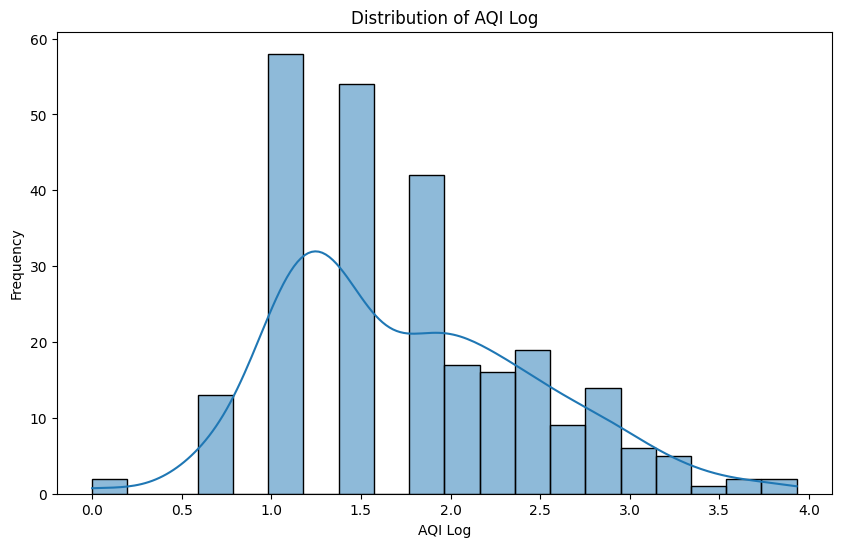

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Stien til din modificerede fil
file_path = 'modified_c4_epa_air_quality.csv'

# Indlæs data
df = pd.read_csv(file_path)

# Opret histogrammet
plt.figure(figsize=(10, 6))
sns.histplot(df['aqi_log'], bins=20, kde=True) # kde=True tilføjer den glatte tæthedslinje

# Tilføj titler og labels
plt.title('Distribution of AQI Log')
plt.xlabel('AQI Log')
plt.ylabel('Frequency')

# Vis plottet (hvis du kører i f.eks. Jupyter Notebook)
plt.show()

# Eller gem det
# plt.savefig('aqi_log_histogram.png')

In [19]:
aqi_log_mean = data['aqi_log'].mean()

In [20]:
aqi_log_mean

np.float64(1.7669210929985582)

In [21]:
aqi_log_std = data['aqi_log'].std()

In [22]:
aqi_log_std

np.float64(0.7147155520223721)

In [25]:
# 3. Definer variabel for den nedre grænse (lower limit)
# Formlen: Gennemsnit - 1 * Standardafvigelse
lower_limit = aqi_log_mean - 1 * aqi_log_std

# Print resultaterne
print(f"Gennemsnit: {aqi_log_mean:.4f}")
print(f"Standardafvigelse: {aqi_log_std:.4f}")
print(f"Lower limit (1 std under mean): {lower_limit:.4f}")

Gennemsnit: 1.7669
Standardafvigelse: 0.7147
Lower limit (1 std under mean): 1.0522


In [26]:
# Formlen: Gennemsnit + 1 * Standardafvigelse
upper_limit = aqi_log_mean + 1 * aqi_log_std

# Print resultaterne
print(f"Gennemsnit: {aqi_log_mean:.4f}")
print(f"Standardafvigelse: {aqi_log_std:.4f}")
print(f"Upper limit (1 std over mean): {upper_limit:.4f}")

Gennemsnit: 1.7669
Standardafvigelse: 0.7147
Upper limit (1 std over mean): 2.4816


In [27]:
# 4. Find alle rækker, der ligger MELLEM de to grænser
# Vi bruger en 'mask' (et filter) til at tælle rækkerne
within_1_std = ((df['aqi_log'] >= lower_limit) & (df['aqi_log'] <= upper_limit)).mean() * 100

# 5. Print resultatet
print(f"Procentdel af data inden for 1 standardafvigelse: {within_1_std:.2f}%")

Procentdel af data inden for 1 standardafvigelse: 76.15%


In [28]:
# Define variable for lower limit, 2 standard deviations below the mean.
lower_limit2 = aqi_log_mean - 2 * aqi_log_std

# Print resultaterne
print(f"Gennemsnit: {aqi_log_mean:.4f}")
print(f"Standardafvigelse: {aqi_log_std:.4f}")
print(f"Lower limit (2 std under mean): {lower_limit2:.4f}")

Gennemsnit: 1.7669
Standardafvigelse: 0.7147
Lower limit (2 std under mean): 0.3375


In [29]:
upper_limit2 = aqi_log_mean + 2 * aqi_log_std

# Print resultaterne
print(f"Gennemsnit: {aqi_log_mean:.4f}")
print(f"Standardafvigelse: {aqi_log_std:.4f}")
print(f"Upper limit (2 std over mean): {upper_limit2:.4f}")

Gennemsnit: 1.7669
Standardafvigelse: 0.7147
Upper limit (2 std over mean): 3.1964


In [30]:
within_2_std = ((df['aqi_log'] >= lower_limit2) & (df['aqi_log'] <= upper_limit2)).mean() * 100

In [31]:
print(within_2_std)

95.76923076923077


In [32]:
upper_limit3 = aqi_log_mean + 3 * aqi_log_std

# Print resultaterne
print(f"Gennemsnit: {aqi_log_mean:.4f}")
print(f"Standardafvigelse: {aqi_log_std:.4f}")
print(f"Upper limit (3 std over mean): {upper_limit3:.4f}")

Gennemsnit: 1.7669
Standardafvigelse: 0.7147
Upper limit (3 std over mean): 3.9111


In [34]:
lower_limit3 = aqi_log_mean - 3 * aqi_log_std
upper_limit3 = aqi_log_mean + 3 * aqi_log_std
within_3_std = ((data['aqi_log'] >= lower_limit3) & (data['aqi_log'] <= upper_limit3)).mean() * 100
print(within_3_std)

99.61538461538461


In [35]:
# 3. Beregn z-score for hver række og gem i en ny kolonne 'z_score'
# Formlen for z-score er: (værdi - gennemsnit) / standardafvigelse
data['z_score'] = (data['aqi_log'] - aqi_log_mean) / aqi_log_std

# 5. Vis de første par rækker for at tjekke resultatet
print(data[['aqi_log', 'z_score']].head())

    aqi_log   z_score
0  2.079442  0.437265
1  1.791759  0.034753
2  1.098612 -0.935070
3  1.386294 -0.532557
4  1.386294 -0.532557


In [37]:
# 2. Find alle outliers (hvor z-score er > 3 eller < -3)
# Vi bruger .abs() for at få den numeriske værdi (fjerner minus-tegnet)
outliers = data[data['z_score'].abs() > 3]

# 3. Vis resultatet
print("--- Fundne outliers (z-score > 3) ---")
if len(outliers) > 0:
    print(outliers[['aqi_log', 'z_score']])
else:
    print("Der blev ikke fundet nogen ekstreme outliers i dette datasæt.")

# Hvis du vil se rækker, der er tæt på at være outliers (mellem 2 og 3):
potential_outliers = df[(data['z_score'].abs() > 2) & (data['z_score'].abs() <= 3)]
print(f"\nAntal potentielle outliers (mellem 2 og 3): {len(potential_outliers)}")

--- Fundne outliers (z-score > 3) ---
      aqi_log   z_score
244  3.931826  3.029044

Antal potentielle outliers (mellem 2 og 3): 10


In [38]:
# 1 Find rækker, der ligger UDEN FOR disse grænser
outliers_3std = data[(data['aqi_log'] < lower_limit3) | (data['aqi_log'] > upper_limit3)]

# 2. Vis de rækker, der er outliers
print(outliers_3std)

     date_local state_name county_name city_name local_site_name  \
244  2018-01-01    Arizona    Maricopa   Phoenix    WEST PHOENIX   

      parameter_name   units_of_measure   aqi_log   z_score  
244  Carbon monoxide  Parts per million  3.931826  3.029044  
